### 1. Loading Training Images and Training the CNN.
Changing "base_dir" changes what images are being used during training, Spatial or Fourier Domain.

In [ ]:
# ==========================================================
# SIMPLE CNN 128x128 — ROBUST TRAINING WITH DATA VERIFICATION
# ==========================================================

import os
import csv
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger

# ========================================
# 1. PATH CONFIGURATIONS
# ========================================
drive.mount('/content/drive')

# Force training from scratch
TREINAR_DO_ZERO = True

# Class mapping (8 training classes)
class_mapping = {
    'circulo_raio20': -1.0,
    'circulo_raio15': -0.75,
    'circulo_raio10': -0.5,
    'circulo_raio5': -0.25,
    'quadrado_lado10': 0.25,
    'quadrado_lado20': 0.5,
    'quadrado_lado30': 0.75,
    'quadrado_lado40': 1.0
}

#FOURIER DOMAIN:
base_dir = '/content/drive/MyDrive/Projeto Mestrado/imagens/transformadas_fourier'
checkpoint_path = '/content/drive/MyDrive/Defesa/CNN_Dom_Fourier/CNN_8Classes_128px_Dom_Fourier.keras'
log_csv_path = '/content/drive/MyDrive/Defesa/CNN_Dom_Fourier/log_treinamento_CNN_8Classes.csv'

#SPATIAL DOMAIN:
#base_dir = '/content/drive/MyDrive/Projeto Mestrado/imagens/convolucoes'
#checkpoint_path = '/content/drive/MyDrive/Defesa/CNN_Dom_Espacial/CNN_8Classes_128px_Dom_Espacial.keras'
#log_csv_path = '/content/drive/MyDrive/Defesa/CNN_Dom_Espacial/log_treinamento_CNN_8Classes_Dom_Espacial.csv'

IMG_SIZE = (128, 128)
VALID_EXT = ('.jpg', '.jpeg', '.png')

# ========================================
# 2. MANUAL LOGGER
# ========================================
class ManualLogger(keras.callbacks.Callback):
    def __init__(self, path):
        self.path = path
        if not os.path.exists(self.path):
            with open(self.path, 'w', newline='') as f:
                csv.writer(f).writerow(['epoch','loss','mae','val_loss','val_mae'])

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        with open(self.path, 'a', newline='') as f:
            csv.writer(f).writerow([
                epoch,
                f"{logs.get('loss',0):.6f}",
                f"{logs.get('mae',0):.6f}",
                f"{logs.get('val_loss',0):.6f}",
                f"{logs.get('val_mae',0):.6f}",
            ])

# ========================================
# 3. VERIFICATION + ROBUST DATA LOADING
# ========================================
def load_images_with_verification(base_dir):
    imgs = []
    labels = []
    total_expected = 0
    total_loaded = 0
    total_errors = 0

    print("\n================ DATASET VERIFICATION ================\n")

    for folder, target in class_mapping.items():
        path = os.path.join(base_dir, folder)

        if not os.path.exists(path):
            print(f"[ERROR] Folder not found: {folder}")
            continue

        files = [f for f in os.listdir(path) if f.lower().endswith(VALID_EXT)]
        total_expected += len(files)

        class_loaded = 0
        class_errors = 0

        for fname in sorted(files):
            img_path = os.path.join(path, fname)
            try:
                img = load_img(
                    img_path,
                    color_mode='grayscale',
                    target_size=IMG_SIZE
                )
                img = img_to_array(img) / 255.0  # GLOBAL NORMALIZATION

                imgs.append(img)
                labels.append(target)
                class_loaded += 1

            except Exception as e:
                class_errors += 1
                total_errors += 1
                print(f"[WARNING] Corrupted image skipped: {fname}")

        total_loaded += class_loaded

        print(f"Class: {folder}")
        print(f"  - Files found:    {len(files)}")
        print(f"  - Images loaded:  {class_loaded}")
        print(f"  - Errors/Skipped: {class_errors}\n")

    print("=============== GLOBAL SUMMARY ===============")
    print(f"Total expected: {total_expected}")
    print(f"Total loaded:   {total_loaded}")
    print(f"Total errors:   {total_errors}")

    if total_loaded == 0:
        raise ValueError("No images were loaded! Please verify the directory path.")

    return np.array(imgs), np.array(labels)

# Execute data loading
X, y = load_images_with_verification(base_dir)

# ========================================
# 4. TRAIN / TEST SPLIT
# ========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"\nTrain shape:      {X_train.shape}")
print(f"Validation shape: {X_test.shape}")

# ========================================
# 5. SIMPLE CNN ARCHITECTURE
# ========================================
def build_cnn():
    return models.Sequential([
        layers.Input(shape=(128,128,1)),

        layers.Conv2D(32,(5,5),strides=2,padding='same',
                      kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64,(3,3),strides=2,padding='same',
                      kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128,(3,3),padding='same',
                      kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)  # Linear regression output
    ])

# ========================================
# 6. SAFE MODEL INITIALIZATION / LOADING
# ========================================
if TREINAR_DO_ZERO:
    print("\n[INFO] Training from SCRATCH requested.")
    model = build_cnn()
else:
    if os.path.exists(checkpoint_path):
        print("\n[INFO] Resuming training from checkpoint...")
        model = keras.models.load_model(checkpoint_path)
    else:
        print("\n[INFO] No checkpoint found. Creating a new model instance.")
        model = build_cnn()

# ========================================
# 7. MODEL COMPILATION
# ========================================
model.compile(
    optimizer=optimizers.Adam(learning_rate=2e-4),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=['mae']
)

# ========================================
# 8. CALLBACKS
# ========================================
callbacks = [
    ManualLogger(log_csv_path),

    ModelCheckpoint(
        checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    EarlyStopping(
        monitor='val_loss',
        patience=25,
        restore_best_weights=True,
        verbose=1
    ),

    # Backup training log
    CSVLogger(log_csv_path.replace('.csv', '_keras.csv'), append=True)
]

# ========================================
# 9. TRAINING EXECUTION
# ========================================
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=250,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# ========================================
# 10. LEARNING CURVE PLOT
# ========================================
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Huber)', fontsize=12)
plt.title('CNN 8 Classes Training Dynamics - Fourier Domain (128x128)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()

### 2. Testing CNN's Performance:
Changing "model_path" changes which model you are loading (CNN trained with Fourier or Spatial Images)
Changing "test_directory" changes what images you are loading to apply the model to, If you are testing Fourier Images, Load Fourier CNN and Fourier testing Images, if Spatial, Load CNN that was trained with Spatial Domain Images and Load Spatial Domain test images

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
--- Loading model: CNN_8Classes_128px_Dom_Fourier.keras ---
--- Loading test images ---
Success! 140 images loaded. Running predictions...


4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step
Generating performance charts...


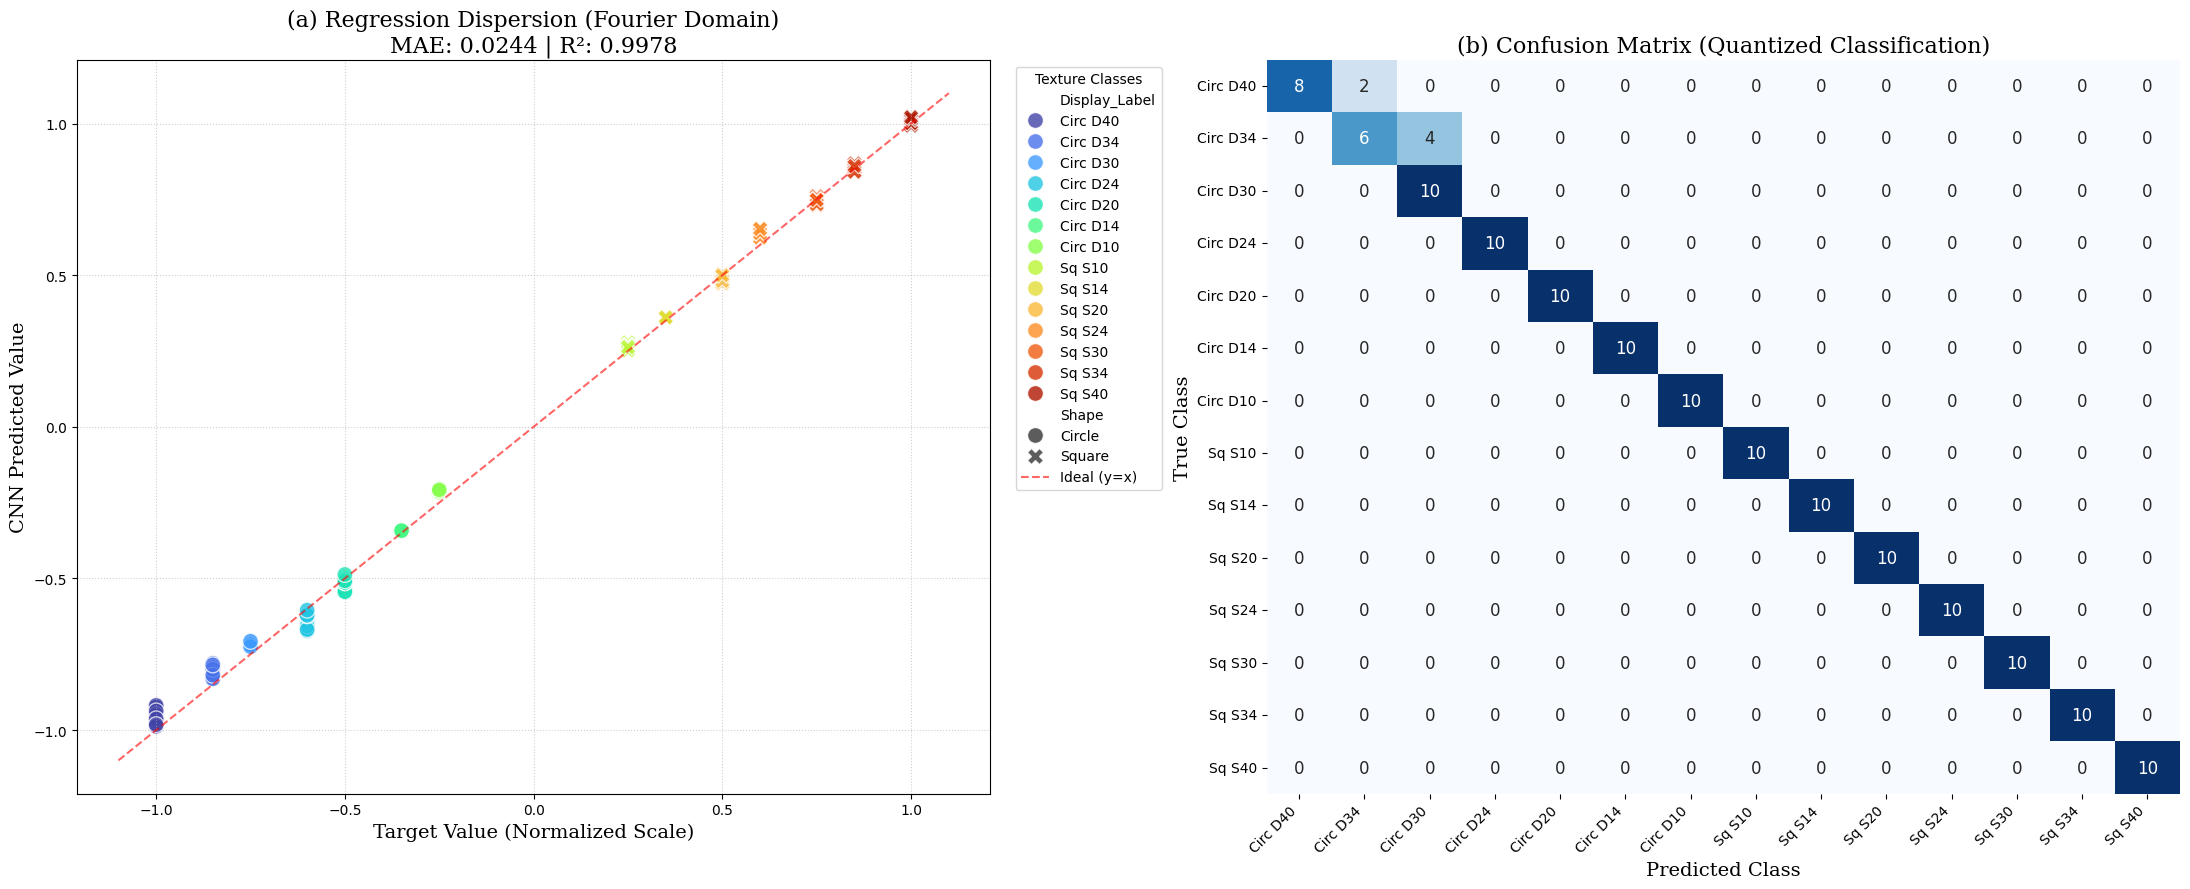

Process successfully completed! Chart saved as 'fourier_results_final.png'.


In [ ]:
# ==========================================================
# INTEGRATED TEST SCRIPT: LOADING, PREDICTION, AND PERFORMANCE ANALYSIS
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import mean_absolute_error, r2_score, confusion_matrix
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive/')

# 2. Path Configurations

#FOURIER DOMAIN:
model_path = '/content/drive/MyDrive/Defesa/CNN_Dom_Fourier/CNN_8Classes_128px_Dom_Fourier.keras'
test_directory = '/content/drive/MyDrive/Projeto Mestrado/imagens_teste_e_previsao'

#SPATIAL DOMAIN:
#model_path = '/content/drive/MyDrive/Defesa/CNN_Dom_Espacial/CNN_8Classes_128px_Dom_Espacial.keras'
#test_directory = '/content/drive/MyDrive/Projeto Mestrado/imagens_spotnoise_test_final/convolucoes'

# 3. Corrected Target Mapping for the 14 Continuous Classes
mapping_y_true = {
    'circulo_raio20': -1.0,  'circulo_raio17': -0.85, 'circulo_raio15': -0.75,
    'circulo_raio12': -0.60, 'circulo_raio10': -0.50, 'circulo_raio7': -0.35,
    'circulo_raio5': -0.25,
    'quadrado_lado10': 0.25, 'quadrado_lado14': 0.35, 'quadrado_lado20': 0.50,
    'quadrado_lado24': 0.60, 'quadrado_lado30': 0.75, 'quadrado_lado34': 0.85,
    'quadrado_lado40': 1.0
}

display_labels = [
    'Circ D40', 'Circ D34', 'Circ D30', 'Circ D24', 'Circ D20', 'Circ D14', 'Circ D10',
    'Sq S10', 'Sq S14', 'Sq S20', 'Sq S24', 'Sq S30', 'Sq S34', 'Sq S40'
]

target_values = np.array(list(mapping_y_true.values()))

# 4. Optimized Image Loading Function
def load_test_images(test_directory):
    images = []
    folder_names = []
    valid_ext = ('.jpg', '.jpeg', '.png')

    for root, _, files in os.walk(test_directory):
        folder_name = os.path.basename(root)

        if folder_name in mapping_y_true:
            for file in sorted(files):
                if file.lower().endswith(valid_ext):
                    image_path = os.path.join(root, file)

                    image = load_img(
                        image_path,
                        color_mode='grayscale',
                        target_size=(128, 128)
                    )
                    image = img_to_array(image) / 255.0

                    images.append(image)
                    folder_names.append(folder_name)

    return np.array(images), folder_names

# 5. Model and Data Execution
print(f"--- Loading model: {os.path.basename(model_path)} ---")
model = keras.models.load_model(model_path)

print("--- Loading test images ---")
X_test_images, folder_names = load_test_images(test_directory)

# 6. Safety Verification and Output Generation
if len(X_test_images) == 0:
    print("[ERROR] No images found in the specified directory!")
else:
    print(f"Success! {len(X_test_images)} images loaded. Running predictions...")

    # Model inference
    predictions = model.predict(X_test_images).flatten()

    # Structuring results into a DataFrame for visual analysis
    df_results = pd.DataFrame({
        'Category': folder_names,
        'Predicted': predictions,
        'Target': [mapping_y_true[name] for name in folder_names]
    })

    # Label processing and categorical ordering for plot axes
    df_results['Display_Label'] = df_results['Category'].apply(
        lambda x: x.replace('circulo_raio20', 'Circ D40').replace('circulo_raio17', 'Circ D34')
                   .replace('circulo_raio15', 'Circ D30').replace('circulo_raio12', 'Circ D24')
                   .replace('circulo_raio10', 'Circ D20').replace('circulo_raio7', 'Circ D14')
                   .replace('circulo_raio5', 'Circ D10').replace('quadrado_lado10', 'Sq S10')
                   .replace('quadrado_lado14', 'Sq S14').replace('quadrado_lado20', 'Sq S20')
                   .replace('quadrado_lado24', 'Sq S24').replace('quadrado_lado30', 'Sq S30')
                   .replace('quadrado_lado34', 'Sq S34').replace('quadrado_lado40', 'Sq S40')
    )
    df_results['Display_Label'] = pd.Categorical(df_results['Display_Label'], categories=display_labels, ordered=True)
    df_results['Shape'] = df_results['Category'].apply(lambda x: 'Square' if 'quadrado' in x.lower() else 'Circle')

    # Regression Metrics Calculation
    mae = mean_absolute_error(df_results['Target'], df_results['Predicted'])
    r2 = r2_score(df_results['Target'], df_results['Predicted'])

    # 7. Combined Plotting: (a) Regression Dispersion + (b) Confusion Matrix
    print("Generating performance charts...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

    # --- Subplot (a): Colored Scatter Plot ---
    sns.scatterplot(data=df_results, x='Target', y='Predicted', hue='Display_Label',
                    style='Shape', s=130, alpha=0.8, ax=ax1, palette='turbo')
    ax1.plot([-1.1, 1.1], [-1.1, 1.1], 'r--', alpha=0.6, label='Ideal (y=x)')
    ax1.set_title(f'(a) Regression Dispersion (Fourier Domain)\nMAE: {mae:.4f} | R²: {r2:.4f}', fontsize=16, fontname="serif")
    ax1.set_xlabel('Target Value (Normalized Scale)', fontsize=14, fontname="serif")
    ax1.set_ylabel('CNN Predicted Value', fontsize=14, fontname="serif")
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(title='Texture Classes', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

    # --- Subplot (b): Proximity-Based Confusion Matrix ---
    indices_pred = [np.argmin(np.abs(target_values - p)) for p in predictions]
    indices_true = [np.argmin(np.abs(target_values - t)) for t in df_results['Target'].values]
    cm = confusion_matrix(indices_true, indices_pred, labels=range(len(target_values)))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
                xticklabels=display_labels, yticklabels=display_labels, cbar=False, annot_kws={"size": 12})
    ax2.set_title('(b) Confusion Matrix (Quantized Classification)', fontsize=16, fontname="serif")
    ax2.set_xlabel('Predicted Class', fontsize=14, fontname="serif")
    ax2.set_ylabel('True Class', fontsize=14, fontname="serif")
    plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

    # Layout optimization and saving in high resolution (Springer standard)
    plt.tight_layout()
    plt.savefig('fourier_results_final.png', dpi=500, bbox_inches='tight')
    plt.show()
    print("Process successfully completed! Chart saved as 'fourier_results_final.png'.")

### 3. Grapich that compares both trainings

Success: Training logs loaded successfully!


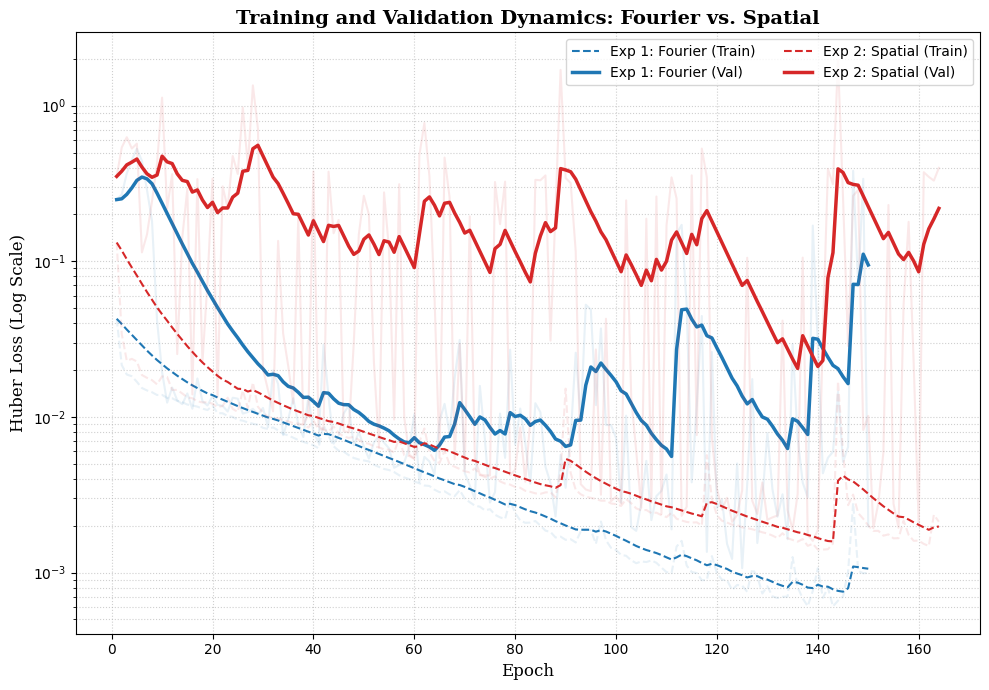

Comparative convergence chart generated and saved as 'convergence_comparison_raw_data.png'!


In [ ]:
# ==========================================================
# CONVERGENCE COMPARISON SCRIPT: FOURIER VS. SPATIAL DOMAIN
# ==========================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Mount Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Training Logs Path Configuration (.csv)
path_spatial = '/content/drive/MyDrive/Defesa/CNN_Dom_Espacial/log_treinamento_CNN_8Classes_Dom_Espacial.csv'
path_fourier = '/content/drive/MyDrive/Defesa/CNN_Dom_Fourier/log_treinamento_CNN_8Classes.csv'

# Secure data loading
try:
    df_s = pd.read_csv(path_spatial)
    df_f = pd.read_csv(path_fourier)
    print("Success: Training logs loaded successfully!")
except FileNotFoundError as e:
    print(f"[ERROR] Log file not found: {e}")
    raise

# 3. Smoothing Function via Exponential Moving Average (EMA)
def smooth(points, factor=0.85):
    smoothed = []
    for p in points:
        if smoothed:
            previous = smoothed[-1]
            smoothed.append(previous * factor + p * (1 - factor))
        else:
            smoothed.append(p)
    return smoothed

# 4. Academic-Standard High-Resolution Plotting
plt.figure(figsize=(10, 7))

# Color palette selection (Blue for Fourier, Red for Spatial)
c_fourier = '#1f77b4'
c_spatial = '#d62728'

# --- EXPERIMENT 1: FOURIER DOMAIN ---
# Raw curves (High transparency to minimize visual noise)
plt.plot(df_f['epoch']+1, df_f['loss'], color=c_fourier, alpha=0.1, linestyle='--')
plt.plot(df_f['epoch']+1, df_f['val_loss'], color=c_fourier, alpha=0.1, linestyle='-')
# Smoothed trends (EMA)
plt.plot(df_f['epoch']+1, smooth(df_f['loss']), color=c_fourier,
         linestyle='--', linewidth=1.5, label='Exp 1: Fourier (Train)')
plt.plot(df_f['epoch']+1, smooth(df_f['val_loss']), color=c_fourier,
         linestyle='-', linewidth=2.5, label='Exp 1: Fourier (Val)')

# --- EXPERIMENT 2: SPATIAL DOMAIN ---
# Raw curves (High transparency)
plt.plot(df_s['epoch']+1, df_s['loss'], color=c_spatial, alpha=0.1, linestyle='--')
plt.plot(df_s['epoch']+1, df_s['val_loss'], color=c_spatial, alpha=0.1, linestyle='-')
# Smoothed trends (EMA)
plt.plot(df_s['epoch']+1, smooth(df_s['loss']), color=c_spatial,
         linestyle='--', linewidth=1.5, label='Exp 2: Spatial (Train)')
plt.plot(df_s['epoch']+1, smooth(df_s['val_loss']), color=c_spatial,
         linestyle='-', linewidth=2.5, label='Exp 2: Spatial (Val)')

# 5. Axes Formatting (Springer Academic Specifications)
plt.yscale('log')
plt.xlabel('Epoch', fontsize=12, fontname="serif")
plt.ylabel('Huber Loss (Log Scale)', fontsize=12, fontname="serif")
plt.title('Training and Validation Dynamics: Fourier vs. Spatial',
          fontsize=14, fontname="serif", fontweight='bold')

plt.grid(True, which="both", linestyle=':', alpha=0.6)
plt.legend(frameon=True, loc='upper right', fontsize=10, ncol=2)

plt.tight_layout()

# Saving figure in 300 DPI
output_filename = 'convergence_comparison_raw_data.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"Comparative convergence chart generated and saved as '{output_filename}'!")